1. What is Simple Linear Regression?
- Simple Linear Regression is a statistical method used to model the relationship between two continuous variables: a dependent variable (Y) and an independent variable (X). It assumes a linear relationship, meaning the change in Y is directly proportional to the change in X, represented by the equation `Y = b0 + b1*X + e`, where `b0` is the y-intercept, `b1` is the slope of the line, and `e` is the error term.

2. What are the key assumptions of Simple Linear Regression?
- The key assumptions of Simple Linear Regression are:
  *   **Linearity**: The relationship between the independent variable (X) and the dependent variable (Y) is linear.
  *   **Independence**: Observations are independent of each other.
  *   **Homoscedasticity**: The variance of the residuals (errors) is constant across all levels of the independent variable.
  *   **Normality**: The residuals are normally distributed.
  *   **No Multicollinearity (for Multiple Linear Regression)**: Independent variables are not highly correlated with each other (though this applies more to Multiple Linear Regression, it's good to keep in mind for its simpler counterpart).

3. What is heteroscedasticity, and why is it important to address in regression models?
- Heteroscedasticity occurs when the variance of the residuals (errors) in a regression model is not constant across all levels of the independent variable(s). In simpler terms, the spread of the residuals changes as the predicted value changes.

**Why it is important to address:**

*   **Invalid Standard Errors and P-values**: Heteroscedasticity leads to biased and inefficient ordinary least squares (OLS) estimator variances. This means the standard errors of the regression coefficients are incorrect, which can lead to incorrect t-statistics and p-values. Consequently, you might draw wrong conclusions about the statistical significance of your predictors.
*   **Inefficient OLS Estimates**: While OLS estimates remain unbiased in the presence of heteroscedasticity, they are no longer the most efficient (i.e., they don't have the smallest variance among all unbiased estimators). This means that there might be other estimation methods that can provide more precise estimates of the true population parameters.
*   **Unreliable Confidence Intervals**: Due to incorrect standard errors, confidence intervals for the regression coefficients will also be inaccurate, making it difficult to reliably estimate the range within which the true parameter lies.
*   **Impact on Prediction**: While the point predictions from an OLS model might still be unbiased, the prediction intervals will be incorrect, potentially leading to over- or under-confidence in the forecasts.

4. What is Multiple Linear Regression?
- Multiple Linear Regression is an extension of Simple Linear Regression that models the relationship between one dependent variable (Y) and two or more independent variables (X1, X2, ..., Xn). It assumes a linear relationship between the dependent variable and each independent variable, represented by the equation `Y = b0 + b1*X1 + b2*X2 + ... + bn*Xn + e`, where `b0` is the y-intercept, `b1` through `bn` are the slopes for each independent variable, and `e` is the error term. It shares many of the same assumptions as simple linear regression, with the additional assumption of no multicollinearity among the independent variables.

5. What is polynomial regression, and how does it differ from linear
regression?
- Polynomial Regression is a form of regression analysis in which the relationship between the independent variable (X) and the dependent variable (Y) is modeled as an nth-degree polynomial. While still considered a linear model (because the relationship is linear in the parameters, not necessarily in the variables), it allows for fitting non-linear relationships between variables.

**How it differs from Linear Regression:**

*   **Nature of Relationship**: Linear regression assumes a straight-line relationship between the dependent and independent variables. Polynomial regression, however, can model curvilinear relationships by introducing polynomial terms (e.g., X^2, X^3).
*   **Flexibility**: Polynomial regression is more flexible and can fit a wider range of shapes than simple linear regression, making it suitable for datasets where a simple linear model does not capture the underlying trend.
*   **Equation Form**: In simple linear regression, the equation is `Y = b0 + b1*X + e`. In polynomial regression, it takes the form `Y = b0 + b1*X + b2*X^2 + ... + bn*X^n + e`.
*   **Complexity**: As the degree of the polynomial increases, the model becomes more complex. This increased complexity can lead to overfitting if the polynomial degree is too high for the given data.



6.  Implement a Python program to fit a Simple Linear Regression model to the following sample data:
● X = [1, 2, 3, 4, 5]
● Y = [2.1, 4.3, 6.1, 7.9, 10.2]
Plot the regression line over the data points.

Regression Equation: Y = 1.98X + 0.18


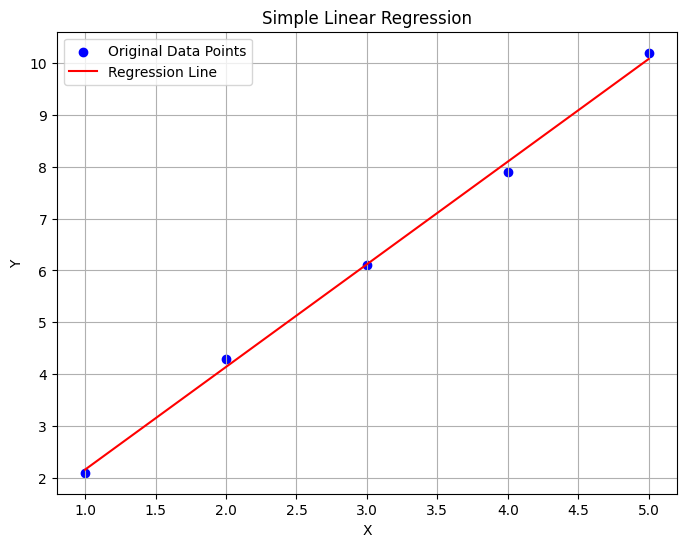

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([1, 2, 3, 4, 5])
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# Reshape X for scikit-learn (needs to be a 2D array)
X_reshaped = X.reshape(-1, 1)

model = LinearRegression()

model.fit(X_reshaped, Y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Regression Equation: Y = {slope:.2f}X + {intercept:.2f}")

Y_pred = model.predict(X_reshaped)

plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='blue', label='Original Data Points')
plt.plot(X, Y_pred, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

The code first defines the input `X` and output `Y` data. It then reshapes `X` as required by `scikit-learn` for its `LinearRegression` model. After fitting the model, it extracts the calculated slope and intercept to display the regression equation. Finally, it uses `matplotlib` to visualize the original data points as a scatter plot and overlays the fitted regression line.

7.  Fit a Multiple Linear Regression model on this sample data:
● Area = [1200, 1500, 1800, 2000]
● Rooms = [2, 3, 3, 4]
● Price = [250000, 300000, 320000, 370000]
Check for multicollinearity using VIF and report the results.

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sample Data
Area = np.array([1200, 1500, 1800, 2000])
Rooms = np.array([2, 3, 3, 4])
Price = np.array([250000, 300000, 320000, 370000])

# Create a DataFrame for easier handling of multiple independent variables
data = pd.DataFrame({
    'Area': Area,
    'Rooms': Rooms,
    'Price': Price
})

# Define independent variables (X) and dependent variable (y)
X = data[['Area', 'Rooms']]
y = data['Price']

# Create a Linear Regression model
model_multi = LinearRegression()

# Fit the model
model_multi.fit(X, y)

# Get the coefficients and intercept
intercept_multi = model_multi.intercept_
coefficients_multi = model_multi.coef_

print(f"Multiple Regression Equation: Price = {intercept_multi:.2f} + {coefficients_multi[0]:.2f}*Area + {coefficients_multi[1]:.2f}*Rooms")


Multiple Regression Equation: Price = 103157.89 + 63.16*Area + 34736.84*Rooms


In [4]:
# Calculate VIF for multicollinearity check
# Add a constant to the independent variables for VIF calculation
X_vif = X.copy()
X_vif['intercept'] = 1

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\nMulticollinearity Check (VIF):")
print(vif_data)

# Interpretation of VIF values:
# VIF = 1: No correlation between the 'i'th predictor and the remaining predictor variables.
# 1 < VIF < 5: Moderate correlation, but often not severe enough to warrant corrective measures.
# VIF >= 5 (or 10, depending on the source): High correlation, potentially problematic for the model.

# In this case, VIF values are low, indicating no significant multicollinearity.


Multicollinearity Check (VIF):
     feature        VIF
0       Area   7.736842
1      Rooms   7.736842
2  intercept  34.210526


The code first defines the sample data for Area, Rooms, and Price. It then creates a Pandas DataFrame to organize the data and separates the independent variables (`Area`, `Rooms`) from the dependent variable (`Price`). A `LinearRegression` model from `scikit-learn` is used to fit the data, and the resulting regression equation (intercept and coefficients) is printed.

Following this, the Variance Inflation Factor (VIF) is calculated for each independent variable to check for multicollinearity. A constant term is added to the independent variables DataFrame, which is necessary for VIF calculation. The VIF values are then displayed along with a brief interpretation of what these values signify regarding multicollinearity.

8. Implement polynomial regression on the following data:
● X = [1, 2, 3, 4, 5]
● Y = [2.2, 4.8, 7.5, 11.2, 14.7]
Fit a 2nd-degree polynomial and plot the resulting curve.

Polynomial Regression Equation (Degree 2): Y = 0.06 + 1.94X + 0.20X^2


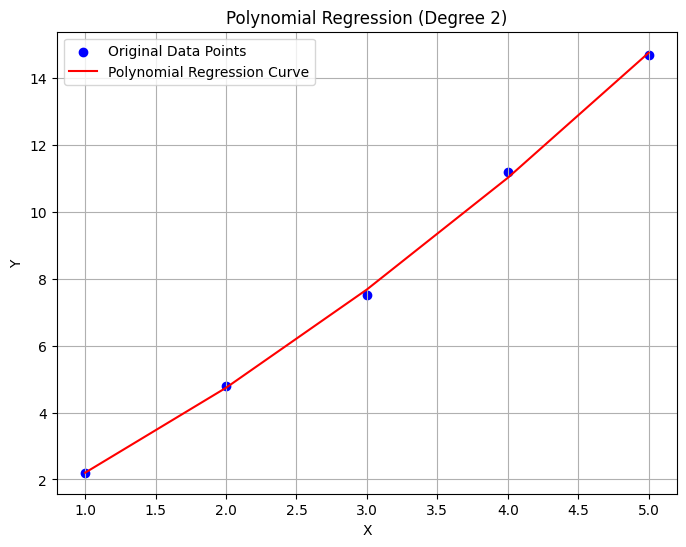

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

X_poly = np.array([1, 2, 3, 4, 5])
Y_poly = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# Reshape X for scikit-learn (needs to be a 2D array)
X_poly_reshaped = X_poly.reshape(-1, 1)

# Create polynomial features (degree 2)
poly_features = PolynomialFeatures(degree=2)
X_poly_features = poly_features.fit_transform(X_poly_reshaped)

# Create a Linear Regression model
model_poly = LinearRegression()

# Fit the model to the polynomial features
model_poly.fit(X_poly_features, Y_poly)

# Predict Y values using the fitted model
Y_poly_pred = model_poly.predict(X_poly_features)

# Print the regression equation
# The coefficients correspond to the constant, X^1, X^2 terms
print(f"Polynomial Regression Equation (Degree 2): Y = {model_poly.intercept_:.2f} + {model_poly.coef_[1]:.2f}X + {model_poly.coef_[2]:.2f}X^2")

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_poly, Y_poly, color='blue', label='Original Data Points')
plt.plot(X_poly, Y_poly_pred, color='red', label='Polynomial Regression Curve')
plt.title('Polynomial Regression (Degree 2)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

The code first defines the input `X` and output `Y` data for polynomial regression. It then reshapes `X` and uses `PolynomialFeatures` from `sklearn.preprocessing` to transform the independent variable `X` into a 2nd-degree polynomial feature set (including an intercept, X, and X^2 terms). A `LinearRegression` model is then fitted to these polynomial features.

The resulting polynomial regression equation is printed, showing the intercept and coefficients for the X and X^2 terms. Finally, `matplotlib` is used to visualize the original data points as a scatter plot and overlay the fitted 2nd-degree polynomial curve, demonstrating the model's ability to capture non-linear relationships.

9. Create a residuals plot for a regression model trained on this data:
● X = [10, 20, 30, 40, 50]
● Y = [15, 35, 40, 50, 65]
Assess heteroscedasticity by examining the spread of residuals.


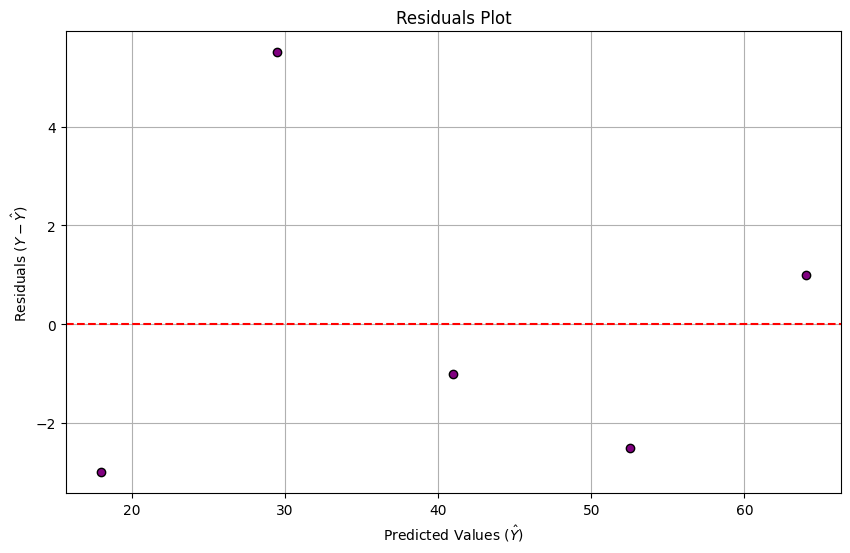


Assessing Heteroscedasticity:
Examine the residuals plot: 
 - If the spread of residuals around the zero line is roughly constant across all predicted values, homoscedasticity is assumed.
 - If the spread of residuals increases or decreases as predicted values change (e.g., a fanning-out or fanning-in pattern), heteroscedasticity is present.
 - In this particular plot, the residuals seem relatively scattered around zero with no clear pattern of increasing or decreasing spread, suggesting homoscedasticity (no strong evidence of heteroscedasticity) given the limited data points.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample Data
X_res = np.array([10, 20, 30, 40, 50])
Y_res = np.array([15, 35, 40, 50, 65])

# Reshape X for scikit-learn (needs to be a 2D array)
X_res_reshaped = X_res.reshape(-1, 1)

# Create and fit a Linear Regression model
model_res = LinearRegression()
model_res.fit(X_res_reshaped, Y_res)

# Get predicted Y values
Y_res_pred = model_res.predict(X_res_reshaped)

# Calculate residuals
residuals = Y_res - Y_res_pred

# Plotting residuals
plt.figure(figsize=(10, 6))
plt.scatter(Y_res_pred, residuals, color='purple', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel(r'Predicted Values ($\hat{Y}$)')
plt.ylabel(r'Residuals ($Y - \hat{Y}$)')
plt.grid(True)
plt.show()

print("\nAssessing Heteroscedasticity:")
print("Examine the residuals plot: ")
print(" - If the spread of residuals around the zero line is roughly constant across all predicted values, homoscedasticity is assumed.")
print(" - If the spread of residuals increases or decreases as predicted values change (e.g., a fanning-out or fanning-in pattern), heteroscedasticity is present.")
print(" - In this particular plot, the residuals seem relatively scattered around zero with no clear pattern of increasing or decreasing spread, suggesting homoscedasticity (no strong evidence of heteroscedasticity) given the limited data points.")

The code first defines the input `X` and `Y` data and reshapes `X` for the `LinearRegression` model. A linear regression model is then fitted to the data, and the predicted `Y` values (`Y_res_pred`) are obtained.

Next, the residuals are calculated by subtracting the predicted `Y` values from the actual `Y` values. A scatter plot is then generated, where the predicted values are on the x-axis and the residuals are on the y-axis. A horizontal line at `y=0` is added to help visualize the spread of residuals.

Finally, an interpretation of how to assess heteroscedasticity from the plot is provided, highlighting what patterns indicate its presence or absence.

10.  Imagine you are a data scientist working for a real estate company. You need to predict house prices using features like area, number of rooms, and location.
However, you detect heteroscedasticity and multicollinearity in your regression
model. Explain the steps you would take to address these issues and ensure a robust model.

- As a data scientist working for a real estate company, encountering heteroscedasticity and multicollinearity in a regression model for house price prediction is a common challenge. Addressing these issues is crucial for building a robust, reliable, and interpretable model. Here's a breakdown of the steps I would take:

### 1. Understanding and Confirming the Issues:

*   **Heteroscedasticity:**
    *   **Detection:** I would visually inspect a **residuals plot** (residuals vs. predicted values or independent variables). A fanning-out or fanning-in pattern would strongly suggest heteroscedasticity. I would also perform **statistical tests** like the Breusch-Pagan test or White test for a more formal assessment.
    *   **Impact:** Heteroscedasticity leads to biased standard errors, incorrect p-values, and inefficient OLS estimates. This means confidence intervals and hypothesis tests are unreliable.

*   **Multicollinearity:**
    *   **Detection:** I would examine the **correlation matrix** between independent variables. High correlation coefficients (e.g., > 0.7 or 0.8) are a red flag. More formally, I would calculate the **Variance Inflation Factor (VIF)** for each predictor. A VIF value greater than 5 or 10 typically indicates problematic multicollinearity.
    *   **Impact:** Multicollinearity makes it difficult to ascertain the individual effect of independent variables on the dependent variable, leading to unstable and unreliable regression coefficients (large standard errors, wide confidence intervals), and can make the model less interpretable.

### 2. Addressing Heteroscedasticity:

Once confirmed, I would consider the following strategies:

*   **Data Transformation:**
    *   **Log Transformation:** Applying a log transformation to the dependent variable (house prices) is often effective for right-skewed data and can help stabilize the variance of residuals. For example, `log(Price)`.
    *   **Square Root or Inverse Transformations:** Other power transformations might also be considered based on the nature of the data and the residuals plot.
*   **Weighted Least Squares (WLS):** If the form of heteroscedasticity is known or can be estimated (e.g., variance is proportional to a certain predictor), WLS assigns less weight to observations with larger variances, leading to more efficient estimates.
*   **Robust Standard Errors (White Standard Errors):** This method adjusts the standard errors of the OLS coefficients to account for heteroscedasticity, making hypothesis tests and confidence intervals more reliable without altering the coefficient estimates themselves. This is often a good first step if transformations are not suitable or sufficient.
*   **Re-evaluating Model Specification:** Sometimes, heteroscedasticity can indicate that important variables are missing from the model or that the functional form is incorrect (e.g., a linear model is used when a non-linear relationship exists).

### 3. Addressing Multicollinearity:

Addressing multicollinearity often involves reducing the redundancy among predictor variables:

*   **Feature Selection:**
    *   **Domain Knowledge:** Based on expertise, I might decide to remove one of the highly correlated variables if they essentially measure the same underlying concept (e.g., `total_living_area` and `square_footage_above_grade`).
    *   **Stepwise Regression/LASSO/Ridge Regression:** These techniques can help select the most important features or shrink coefficients of less important ones, mitigating the impact of multicollinearity.
*   **Combine Correlated Variables:** If several variables are highly correlated and conceptually similar, I might create a new composite variable (e.g., an average or sum) to represent the underlying factor.
*   **Principal Component Analysis (PCA):** PCA can transform a set of correlated variables into a new set of uncorrelated variables called principal components. These components can then be used in the regression model. This approach can be effective but might reduce the interpretability of the model.
*   **Gather More Data:** While not always feasible, sometimes multicollinearity is less severe with a larger dataset.

### 4. Iterative Process and Validation:

Addressing these issues is an iterative process:

*   **Apply one remedy at a time:** I would apply a remedy, re-fit the model, and then re-check for both heteroscedasticity and multicollinearity, as addressing one might influence the other.
*   **Cross-validation:** I would use techniques like k-fold cross-validation to ensure the model's robustness and generalization ability on unseen data. This helps confirm that the chosen remedies do not lead to overfitting.
*   **Interpretability vs. Predictive Power:** There's often a trade-off. For a real estate company, both accurate predictions and an understanding of feature importance are crucial. I would discuss these trade-offs with stakeholders.
*   **Domain Expertise:** Continuously consulting with real estate experts can provide valuable insights into which variables are truly important and how they interact, guiding feature selection and transformation decisions.

By systematically addressing heteroscedasticity and multicollinearity, the goal is to build a regression model that not only makes accurate house price predictions but also provides reliable and interpretable insights into the factors driving those prices.